# Постановка задачи


**Цель работы:** исследование и обработка данных для повышения их качества.

**Краткое описание:** в лабораторной работе приводится поэтапный план изучения и обработки намеренно не предобработанных данных. Необходимо выполнить все этапы плана и оценить результаты преобразований.

# Данные



В папке [Data/lab3](https://drive.google.com/drive/folders/1437z7m5Ut4WUJOhJg1oZz13dtBpxgFKs?usp=share_link) расположена таблица `monster_com_job_sample.com` с данными о вакансиях. Также эти данные с описанием и примерами обработки можно найти на [kaggle](https://www.kaggle.com/code/ankkur13/perfect-dataset-to-get-the-hands-dirty/data#).

##### **Формат данных**

```
country,country_code,date_added,has_expired,job_board,job_description,job_title,job_type,location,organization,page_url,salary,sector,uniq_id
United States of America,US,"",No,jobs.monster.com,"TeamSoft is seeing an IT Support Specialist to join our client in Madison, WI. The ideal candidate must have at least 6 years of experience in the field. They need to be familiar with a variety of the field's concepts, practices, and procedures as this position relies on extensive experience and judgment to plan and accomplish goals. Required Skills:вАҐ Call tracking softwareвАҐ Phone based technical supportвАҐ Problem documentation and communicationвАҐ Remote Desktop Management ToolsвАҐ Respond to customer requestsвАҐ General understanding of LANDeskвАҐ Microsoft Office 2007 SuiteFind out why TeamSoft is the Madison area's technology leader with over 200 IT consultants. Owned, operated, and managed by IT consultants, TeamSoft is the clear choice for your career. Join the TeamSoft family today!Did you know?вАҐ TeamSoft offers salaried options for many positions that include 5 weeks PTO and great benefits!вАҐ TeamSoft has been in business since 1996вАҐ TeamSoft's owners are local IT professionals who possess a wealth of experience in application development, business analysis, and project managementвАҐ TeamSoft's Recruiters are knowledgeable, friendly, and ready to help you make your next great career moveвАҐ TeamSoft offers a full benefits suite to all of our W2 consultants, including a 401k plan with a 100% vested 4% dollar for dollar matchвАҐ Our targeted selection process is designed to get to know your strengths and career interests and provide you with the best chance for success in your new positionвАҐ Our longest running consultant has been with us for 16 yearsвАҐ Consultants can participate in our charitable giving committee. To date, TeamSoft's charitable giving committee has donated over $100,000!TeamSoft is owned by local IT professionals. Our team also has deep experience with IT staffing. Our clients understand this and rely on our expertise. That is why TeamSoft is the Madison Area's largest privately owned IT consulting firm, with more than 200 current consultants! With over 50 active clients, TeamSoft will give you the greatest exposure to the widest range of IT careers.Our owners possess a combined 60+ years of IT consulting experience. Our recruiting and Account Management staff are very well-versed in our client markets. We get you. We know you. We know what you do every day. And we know what you deal with on the job.You take your career seriously and so do we. At TeamSoft you are not just a resume or number. Our goal is to create long-term partnerships with each of our consultants, and according to feedback from many of them, we are very good at this. Click HERE to see what our consultants have to say about working with TeamSoft.TeamSoft -- Promote yourself!TeamSoft is an equal employment opportunity employer functioning under an Affirmative Action Plan.",IT Support Technician Job in Madison,Full Time Employee,"Madison, WI 53702","",http://jobview.monster.com/it-support-technician-job-madison-wi-us-167855963.aspx?mescoid=1500134001001&jobPosition=20,"",IT/Software Development,11d599f229a80023d2f40e7c52cd941e
United States of America,US,"",No,jobs.monster.com,"The Wisconsin State Journal is seeking a flexible and motivated reporter/editor to lead its three-person business desk. WeвАЩre looking for an experienced journalist able to spot trends, be a watchdog and reflect the Madison areaвАЩs vibrant entrepreneurial community. This is a hybrid reporting and editing position that calls for a fleet-footed, multimedia storyteller able to maximize the newspaperвАЩs online presentation while also editing two sections a week. Candidates must have strong news judgment, be well versed in business news and trends and be able to quickly prioritize coverage.At least five yearsвАЩ experience reporting or editing for digital and print platforms desired. To be considered for the position, applicants must apply online.¬†As part of your online application, please attach five samples of your work or links to five recent stories.Wisconsin State Journal, 1901 Fish Hatchery Road, Madison, WI 53713Affirmative Action/Equal Opportunity Employer/Pre-employment drug testing appliesPI94338362Apply Here",Business Reporter/Editor Job in Madison,Full Time,"Madison, WI 53708",Printing and Publishing,http://jobview.monster.com/business-reporter-editor-job-madison-wi-us-167830105.aspx?mescoid=2700437001001&jobPosition=7,"","",e4cbb126dabf22159aff90223243ff2a
...
```

##### **Описание полей**
 - ```country``` — наименование страны;
 - ```country_code``` — код страны;
 - ```date_added``` — дата размещения вакансии;
 - ```has_expired``` — актуальность вакансии;
 - ```job_board``` — агрегатор вакансий, с которого собраны данные;
 - ```job_description``` — описание вакансии;
 - ```job_title``` — наименование должности;
 - ```job_type``` — вид занятости;
 - ```location``` — метоположение организации;
 - ```organization``` — наименование организации;
 - ```page_url``` — ссылка на страницу с вакансией;
 - ```salary``` — заработная плата;
 - ```sector``` — сфера деятельности;
 - ```uniq_id``` — уникальный идентификатор записи о вакансии.

# Понимание данных

In [1]:
import re
import numpy as np
import pandas as pd
import missingno as msno
from matplotlib import pyplot as plt
import seaborn as sns

В датасете есть несколько столбцов, в каждой ячейке которых записано одно и то же значение. Есть столбцы, в которых формат записи значений не стандартизирован. А есть такие, где указана информация, не соответствующая названию столбца.

**Первый этап изучения данных** – понять, какие основные проблемы предстоит решить для каждого из столбцов. Для этого загрузите датасет и выведите случайные несколько строк из него. Постарайтесь понять, что из себя представляют данные в столбцах.

In [2]:
df = pd.read_csv('monster_com_job_sample.csv', encoding='latin1', sep=',')

df.head()

,country,country_code,date_added,has_expired,job_board,job_description,job_title,job_type,location,organization,page_url,salary,sector,uniq_id
0,United States of America,US,NaN,No,jobs.monster.com,TeamSoft is seeing an IT Support Specialist to...,IT Support Technician Job in Madison,Full Time Employee,"Madison, WI 53702",NaN,http://jobview.monster.com/it-support-technici...,NaN,IT/Software Development,11d599f229a80023d2f40e7c52cd941e
1,United States of America,US,NaN,No,jobs.monster.com,The Wisconsin State Journal is seeking a flexi...,Business Reporter/Editor Job in Madison,Full Time,"Madison, WI 53708",Printing and Publishing,http://jobview.monster.com/business-reporter-e...,NaN,NaN,e4cbb126dabf22159aff90223243ff2a
2,United States of America,US,NaN,No,jobs.monster.com,Report this job About the Job DePuy Synthes Co...,Johnson & Johnson Family of Companies Job Appl...,"Full Time, Employee",DePuy Synthes Companies is a member of Johnson...,Personal and Household Services,http://jobview.monster.com/senior-training-lea...,NaN,NaN,839106b353877fa3d896ffb9c1fe01c0
3,United States of America,US,NaN,No,jobs.monster.com,Why Join Altec? If youâre considering a care...,Engineer - Quality Job in Dixon,Full Time,"Dixon, CA",Altec Industries,http://jobview.monster.com/engineer-quality-jo...,NaN,Experienced (Non-Manager),58435fcab804439efdcaa7ecca0fd783
4,United States of America,US,NaN,No,jobs.monster.com,Position ID#Â 76162 # PositionsÂ 1 StateÂ C...,Shift Supervisor - Part-Time Job in Camphill,Full Time Employee,"Camphill, PA",Retail,http://jobview.monster.com/shift-supervisor-pa...,NaN,Project/Program Management,64d0272dc8496abfd9523a8df63c184c


**Задание**

Составьте таблицу, в которой будет содержаться название столбца, тип данных в нем и краткое описание проблем, которые вы заметили при первом взгляде на данные.

| Название столбца | Тип данных | Проблемы                                                                              |
|:-----------------|:-----------|:--------------------------------------------------------------------------------------|
| `country`        | str        | Все значения одинаковые (United States of America) — бесполезен для анализа           |
| `country_code`   | str        | Все значения одинаковые (US) — бесполезен для анализа                                 |
| `date_added`     | str        | Большое количество пропусков (NaN). Нужно преобразовывать в формат datetime           |
| `has_expired`    | str        | Все значения одинаковые (No) — бесполезен для анализа                                 |
| `job_board`      | str        | Все значения одинаковые (jobs.monster.com) — бесполезен для анализа                   |
| `job_description`| str        | Текстовые данные, возможны проблемы с кодировкой и спецсимволами, нет единого формата |
| `job_title`      | str        | Содержит лишние слова (Job in "название города", что никак не поясняет значения)      |
| `job_type`       | str        | Странный формат и много разных вариантов: Full Time, Full Time Employee и т.д.        |
| `location`       | str        | Некоторые данные из других столбцов, не соответствуют названию                        |
| `organization`   | str        | Много пропусков, разные форматы, значения из других столбцов                          |
| `page_url`       | str        | URL-адреса без обработки                                                              |
| `salary`         | str        | Огромное количество пропусков, разные форматы зарплат (за год, за час)                |
| `sector`         | str        | Много пропусков, некоторые значения не относятся к секторам                           |
| `uniq_id`        | str        | Хеш-подобные строки — уникальные идентификаторы, проблем нет                          |


### Оценка пустых ячеек в датасете

Выясните, в каких столбцах, строках и в каком количестве отсутствуют данные:
1. С помощью модуля `pandas` составьте таблицу, где каждому названию столбца будет сопоставлено общее количество ячеек и количество пустых ячеек.
2. Подсчитайте количество строк датасета, в которых пустыми являются более 75% ячеек.
3. Визуализируйте число пропусков в датасете с помощью модуля, построив столбчатую диаграмму. Для удобства можно воспользоваться модулем `missingno`.


,Название столбца,Общее количество ячеек,Количество пустых ячеек
0,country,22000,0
1,country_code,22000,0
2,date_added,22000,21878
3,has_expired,22000,0
4,job_board,22000,0
5,job_description,22000,0
6,job_title,22000,0
7,job_type,22000,1628
8,location,22000,0
9,organization,22000,6867


Количество строк, в которых отсутствует более 75% данных: 0


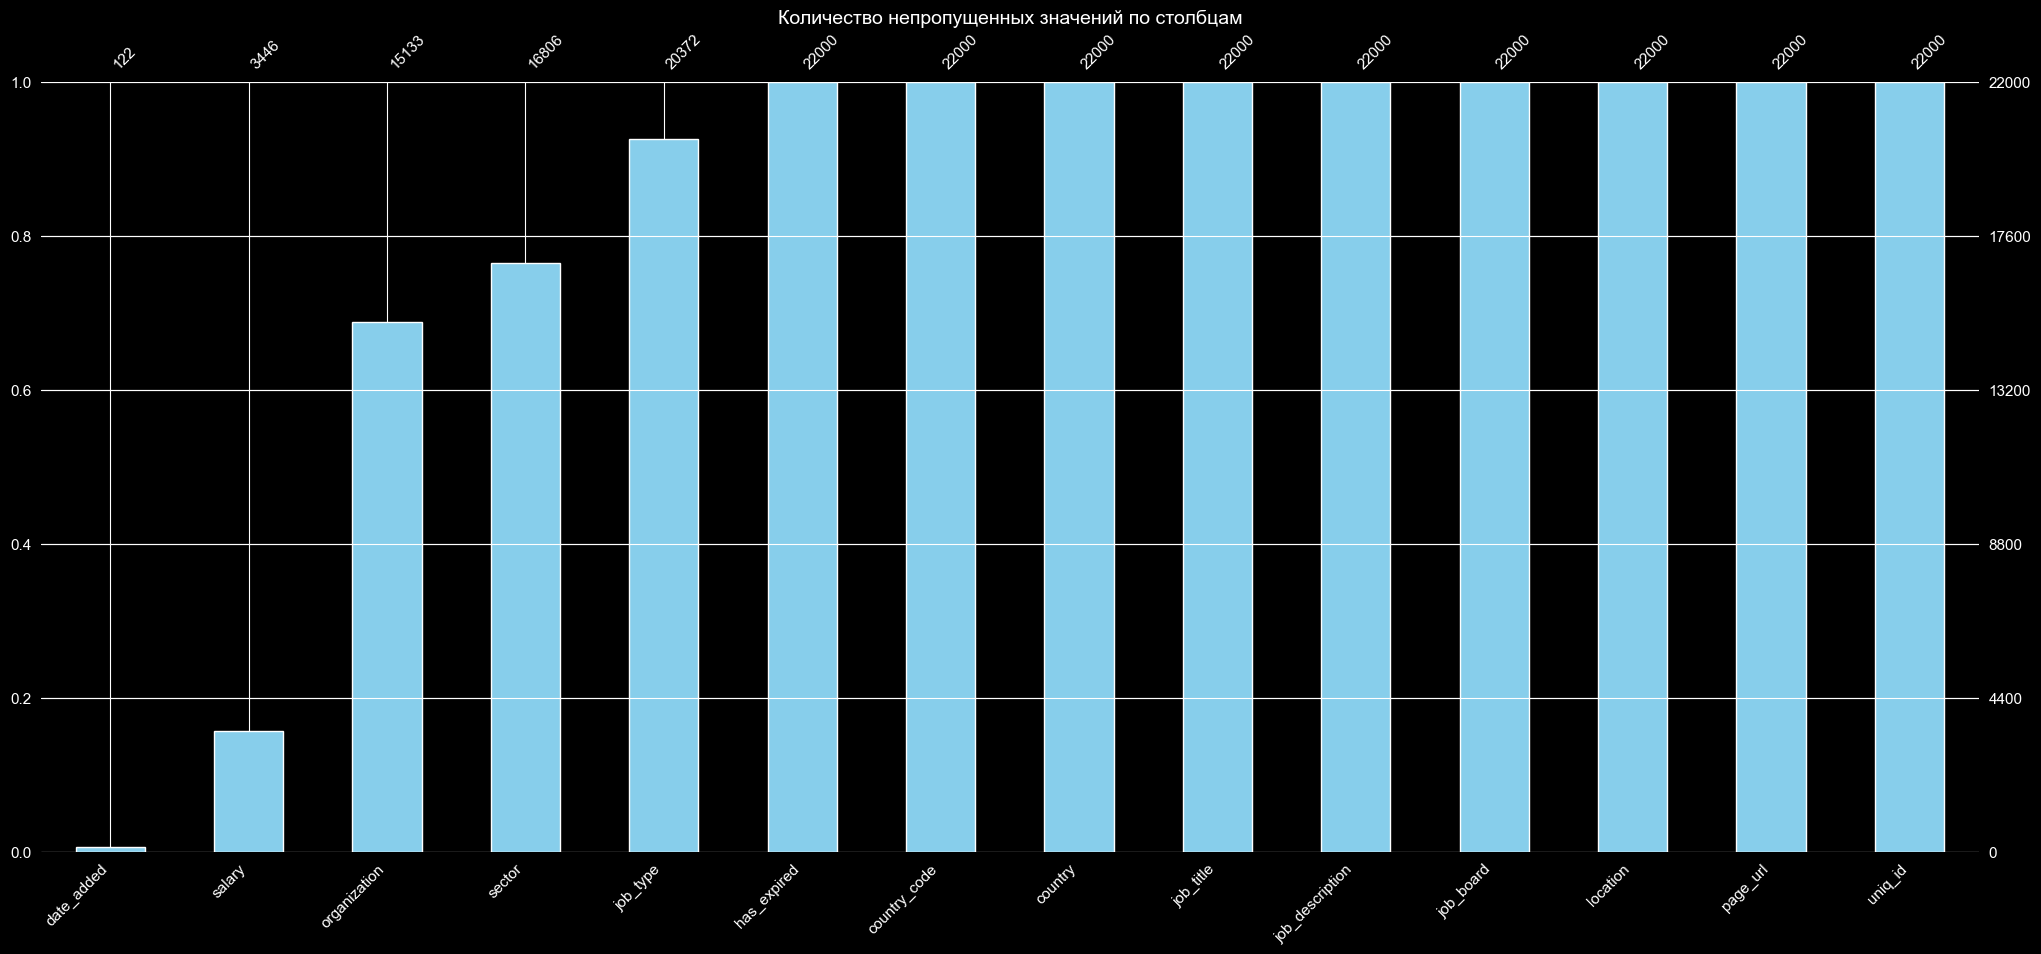

In [3]:
missing_table = pd.DataFrame({
    'Общее количество ячеек': len(df),
    'Количество пустых ячеек': df.isna().sum()
}).reset_index().rename(columns={'index': 'Название столбца'})

display(missing_table)

missing_per_row = df.isna().mean(axis=1)
highly_missing_rows = (missing_per_row > 0.75).sum()

print(f"Количество строк, в которых отсутствует более 75% данных: {highly_missing_rows}")

plt.figure(figsize=(12, 8))

msno.bar(df, color='skyblue', fontsize=11, sort="ascending")

plt.title('Количество непропущенных значений по столбцам', fontsize=14)
plt.show()

Проверьте, как изменится размер датасета, если принять решение удалить все строки, где есть пустые значения. Сделайте выводы.

In [4]:
df_dropped = df.dropna()
print(f'Исходный размер: {len(df)} строк')
print(f'После удаления строк с любыми пропусками: {len(df_dropped)} строк')
print('Вывод: удаление всех строк с пропусками приведёт к потере практически всех имеющихся строк.')
print('Это недопустимо, поэтому нужно использовать другие методы обработки пропусков.')

Исходный размер: 22000 строк
После удаления строк с любыми пропусками: 5 строк
Вывод: удаление всех строк с пропусками приведёт к потере практически всех имеющихся строк.
Это недопустимо, поэтому нужно использовать другие методы обработки пропусков.


### Первичная оценка данных в столбцах

Изучите данные в столбцах датасета, ответив на следующие вопросы:
1. Есть ли столбцы, в которых встречается всего одно значение? Как их можно использовать в анализе?
2. Есть ли такие значения, которые встречаются более чем в одном столбце?
3. Есть ли столбцы, данные в которых не соответствуют названию столбца? Какие это столбцы?

In [5]:
single_value_cols = [col for col in df.columns if df[col].nunique() == 1]
print('Столбцы с одним значением:')
for col in single_value_cols:
    print(f'{col}: {df[col].iloc[0]}')
print()
print('Эти столбцы можно зафиксировать как константы и не подвергать обработке, поскольку это не даст никаких результатов.')
print()

print('Да, есть значения, которые встречаются более чем в одном столбце, например:')
org_values = set(df['location'].dropna().unique())
sector_values = set(df['job_title'].dropna().unique())
overlap = org_values & sector_values
print(f'Пересечение location и job_title: {len(overlap)} общих значений')
if len(overlap) > 0:
    for elem in list(overlap):
        print(f'- {elem}')
print()

incorrect_location = df[df['location'].str.len() > 50]['location'].head(2)
incorrect_sector = df[df['sector'].str.contains('Manager|Experienced', na=False, case=False)]['sector'].unique()[:2]

print("Да, есть некоторые несоответствия:")
print(f"- В столбце 'location' встречаются тексты описаний или названия (job_description, job_title) вместо адресов, например: '{incorrect_location.values[0][:70]}...'")
print(f"- В столбце 'sector' вместо отрасли указан уровень квалификации: \n {'\n '.join(list(incorrect_sector))}")

Столбцы с одним значением:
country: United States of America
country_code: US
has_expired: No
job_board: jobs.monster.com

Эти столбцы можно зафиксировать как константы и не подвергать обработке, поскольку это не даст никаких результатов.

Да, есть значения, которые встречаются более чем в одном столбце, например:
Пересечение location и job_title: 12 общих значений
- Recruiter
- Job Details
- Tax Accountant
- Supplier Quality Engineer
- Field Service Technician
- Business Analyst
- RF Engineer
- Project Manager
- Senior Accountant
- Senior Project Manager
- Project Manager I
- Software Engineer

Да, есть некоторые несоответствия:
- В столбце 'location' встречаются тексты описаний или названия (job_description, job_title) вместо адресов, например: 'DePuy Synthes Companies is a member of Johnson & Johnson's Family of C...'
- В столбце 'sector' вместо отрасли указан уровень квалификации: 
 Experienced (Non-Manager)
 Manager (Manager/Supervisor of Staff)


### Дублирование данных

Для поиска дублирующихся строк выполните следующие действия:
1. В таблице есть столбец `uniq_id`, значения которого, как сказано в описании данных, являются уникальными идентификаторами записей. Проверьте, действительно ли в этом столбце все значения различны.
2. Проверьте, есть ли в таблице другие столбцы, значения которых в каждой строке различны.
3. Если игнорировать столбцы, где все значения различны, найдутся ли такие строки, для которых значения по всем остальным столбцам будут совпадать?

Оцените результаты поиска дубликатов.

In [6]:
uniq_id_unique = df['uniq_id'].nunique()
total_rows = len(df)
if uniq_id_unique == total_rows:
    print("1. Да, значения различны.")
else:
    print("1. Нет, значения повторяются")

all_unique_cols = [col for col in df.columns if df[col].nunique() == total_rows and col != 'uniq_id']
print(f'2. Другие столбцы, где все значения уникальны: {all_unique_cols}')

cols_without_unique = [col for col in df.columns if col not in all_unique_cols and col != 'uniq_id']
duplicates = df.duplicated(subset=cols_without_unique, keep=False)
print(f"3. Есть ли дубликаты: {'да' if len(duplicates) > 0 else 'нет'}")

print('Вывод: uniq_id действительно уникален, также уникальная ссылка на страницу, но полные дубликаты этих столбцов')
print('существуют. Это может означать, что одна и та же вакансия была опубликована')
print('несколько раз с разными ID.')


1. Да, значения различны.
2. Другие столбцы, где все значения уникальны: ['page_url']
3. Есть ли дубликаты: да
Вывод: uniq_id действительно уникален, также уникальная ссылка на страницу, но полные дубликаты этих столбцов
существуют. Это может означать, что одна и та же вакансия была опубликована
несколько раз с разными ID.


# Практические задания

В этом разделе необходимо обработать значения в трех столбцах датасета: `location`, `salary` и `job_type`. Цель обработки – стандартизировать данные в каждом из столбцов так, чтобы их можно было анализировать.

### Задание 1

В задании 1 необходимо провести обработку столбца `location`.

#### Задание 1.1

В столбце `location` представлена информация о местоположении организации, в которой открыта вакансия. Каждое значение столбца `location` содержит информацию о городе, коде штата и почтовом индексе.

Однако не в каждой строке есть все три характеристики местоположения, а также могут встречаться разные комбинации из них, записанные в виде строки в произвольном порядке и с разными разделителями.

Например, может быть указан только код штата, только название города или только индекс. Могут быть указаны любые две характеристики из трех.

**Формулировка задания:**
1. Определите, какие форматы встречаются.
2. Напишите одно или несколько регулярных выражений для поиска выявленных форматов.
3. Визуализируйте количество найденных форматов на столбчатой или круговой диаграмме. Также покажите на ней количество строк, в которых формат определить не удалось. Какие форматы встречаются чаще всего?

Ознакомиться с теоретическим материалом по работе с регулярными выражениями можно [по ссылке](https://colab.research.google.com/drive/1eFHdmt9OROLEDJRNc2wNmz0gpE1O3sKU?usp=sharing).

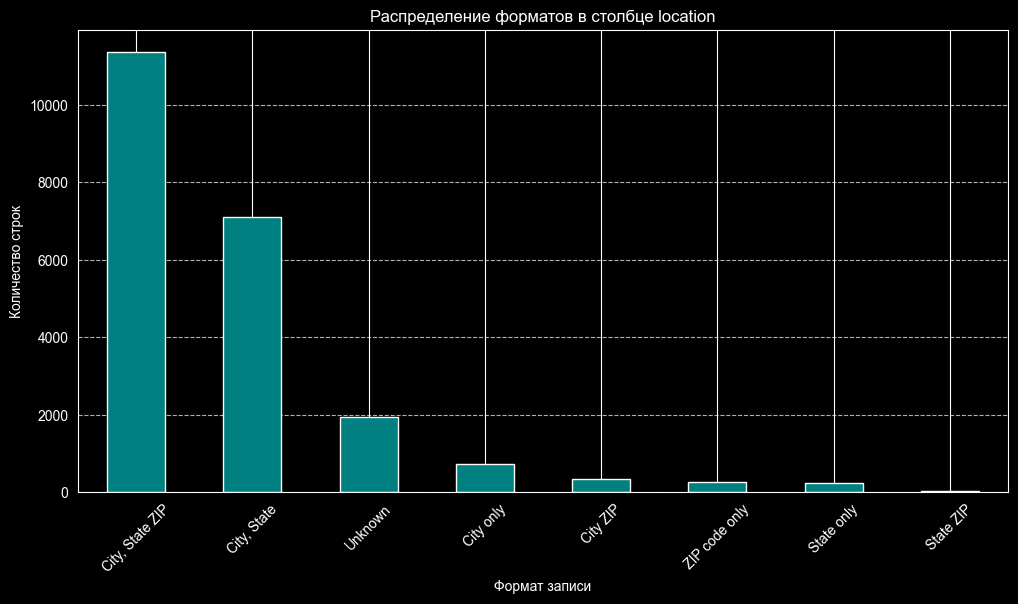

Частота встречаемости форматов:
location_format
City, State ZIP    11372
City, State         7119
Unknown             1943
City only            734
City ZIP             327
ZIP code only        254
State only           230
State ZIP             21
Name: count, dtype: int64


In [7]:
patterns = {
    'City, State ZIP': r'^([A-Za-z\s\.\-]+),\s*([A-Z]{2})\s*(\d{5})$',
    'City, State': r'^([A-Za-z\s\.\-]+),\s*([A-Z]{2})$',
    'State ZIP': r'^([A-Z]{2})\s*(\d{5})$',
    'City ZIP': r'^([A-Za-z\s\.\-]+)\s*(\d{5})$',
    'ZIP code only': r'^(\d{5})$',
    'State only': r'^([A-Z]{2})$',
    'City only': r'^([A-Za-z\s\.\-]+)$'
}

def identify_format(text):
    text = str(text).strip()
    for name, regex in patterns.items():
        if re.match(regex, text):
            return name
    return 'Unknown'

df['location_format'] = df['location'].apply(identify_format)
format_counts = df['location_format'].value_counts()

plt.figure(figsize=(12, 6))
format_counts.plot(kind='bar', color='teal')
plt.title('Распределение форматов в столбце location')
plt.xlabel('Формат записи')
plt.ylabel('Количество строк')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Частота встречаемости форматов:")
print(format_counts)

#### Задание 1.2

В большей части строк удалось извлечь данные из ячейки столбца `location`, но остались и такие, где это не получилось. Вынесите в отдельный датасет записи, в которых не удалось определить формат записи информации о местоположении.

Над оставшимися строками проведите следующие преобразования:
1. Данные о местоположении разделите на 3 столбца: город, код штата, почтовый индекс.
2. Так как значения в столбце `почтовый индекс` являются пятизначными числами, проверьте, что в этом столбце нет чисел с другим количеством разрядов и что все они записаны в формате строки.

In [8]:
unknown_locations_df = df[df['location_format'].isin(['Unknown'])].copy()
df_clean = df[~df['location_format'].isin(['Unknown'])].copy()

def extract_location_parts(row):
    text = str(row['location']).strip()
    fmt = row['location_format']
    city, state, zip_code = None, None, None
    match = re.match(patterns.get(fmt, ''), text)
    if match:
        groups = match.groups()
        if fmt == 'City, State ZIP':
            city, state, zip_code = groups
        elif fmt == 'City, State':
            city, state = groups
        elif fmt == 'City ZIP':
            city, zip_code = groups
        elif fmt == 'State ZIP':
            state, zip_code = groups
        elif fmt == 'City only':
            city = groups[0]
        elif fmt == 'ZIP code only':
            zip_code = groups[0]
        elif fmt == 'State only':
            state = groups[0]
    return pd.Series([city, state, zip_code])

df_clean[['city', 'state_code', 'zip_code']] = df_clean.apply(extract_location_parts, axis=1)

df_clean['zip_code'] = df_clean['zip_code'].astype(str).replace('None', np.nan)

invalid_zips = df_clean[df_clean['zip_code'].notna() & (df_clean['zip_code'].str.len() != 5)]

print(f"Количество некорректных индексов: {len(invalid_zips)}")

display(df_clean[['location', 'city', 'state_code', 'zip_code']].head(10))

Количество некорректных индексов: 0


,location,city,state_code,zip_code
0,"Madison, WI 53702",Madison,WI,53702
1,"Madison, WI 53708",Madison,WI,53708
3,"Dixon, CA",Dixon,CA,NaN
4,"Camphill, PA",Camphill,PA,NaN
5,"Charlottesville, VA",Charlottesville,VA,NaN
6,Contact name Tony Zerio,Contact name Tony Zerio,NaN,NaN
7,"Austin, TX 73301",Austin,TX,73301
8,"Austin, TX 78746",Austin,TX,78746
9,"Chesterfield, MO",Chesterfield,MO,NaN
10,"Berryville, VA 22611",Berryville,VA,22611


#### Задание 1.3*

Рассмотрите отложенную часть выборки (ту, где не удалось данные из столбца `location` разделить на три поля) и сделайте выводы о возможности извлечь из данных город, код штата и почтовый индекс. Извлеките все, что возможно. Что невозможно – оставьте пустым.

In [9]:
known_cities = set(df_clean['city'].dropna().unique())
sorted_cities = sorted(known_cities, key=len, reverse=True)
city_pattern = re.compile(r'\b(' + '|'.join(re.escape(city) for city in sorted_cities) + r')\b', re.IGNORECASE)

def rescue_location_from_text(text, city_pattern):
    if pd.isna(text):
        return (np.nan, np.nan, np.nan)

    text = str(text).strip()

    city_match = city_pattern.search(text)
    city_val = city_match.group(1) if city_match else None

    location_match = re.search(r'Location:\s*([^,\n]+?)\s*,?\s*([A-Z]{2})?\b', text, re.IGNORECASE)
    if location_match:
        state_val = location_match.group(2) if location_match.group(2) else None
        if not state_val:
            state_match = re.search(r'\b([A-Z]{2})\b', text)
            state_val = state_match.group(1) if state_match else None
    else:
        state_match = re.search(r'\b([A-Z]{2})\b', text)
        state_val = state_match.group(1) if state_match else None

    zip_match = re.search(r'\b(\d{5})\b', text)
    zip_val = zip_match.group(1) if zip_match else None
    return (city_val, state_val, zip_val)


results = unknown_locations_df['location'].apply(
    lambda x: rescue_location_from_text(x, city_pattern)
)
unknown_locations_df[['city', 'state_code', 'zip_code']] = pd.DataFrame(
    results.tolist(),
    index=unknown_locations_df.index
)

for col in ['city', 'state_code', 'zip_code']:
    unknown_locations_df[col] = (
        unknown_locations_df[col]
        .astype(str)
        .replace(['None', 'nan', 'NaN', '<NA>'], np.nan)
    )


print("Таблица восстановленных данных:")
display(unknown_locations_df[['location', 'city', 'state_code', 'zip_code']].head(30))

total_unknown = len(unknown_locations_df)
recovered_mask = unknown_locations_df[['city', 'state_code', 'zip_code']].notna().any(axis=1)
recovered = recovered_mask.sum()

print(f"Всего записей: {total_unknown}")
print(f"Восстановлено: {recovered} ({recovered / total_unknown:.1%})")

Таблица восстановленных данных:


,location,city,state_code,zip_code
2,DePuy Synthes Companies is a member of Johnson...,Raynham,MA,NaN
29,"Sr. Process Engineer, Manufacturing",NaN,NaN,NaN
36,"RF System Technician, Field Service",NaN,RF,NaN
44,"Bradford, Vt 05033",NaN,NaN,05033
45,Respiratory Therapist PRN Nights - Kindred Hos...,-,IT,NaN
72,"""Statewide"", CO",NaN,CO,NaN
105,Registered Nurse ICU Full Time Days - Kindred ...,Town and Country,IT,NaN
115,Experienced Registered Nurse-Critical Care/ICU...,-,IT,NaN
135,"Bafb, Aurora 80011",Aurora,NaN,80011
138,Registered Nurse ICU Full Time Nights - Kindre...,Town and Country,IT,NaN


Всего записей: 1943
Восстановлено: 1701 (87.5%)


### Задание 2

В задании 2 необходимо провести обработку столбца `salary`.

#### Задание 2.1

В столбце `salary`, как и в `location`, данные не стандатизированы. В нем в основном можно встретить записи в следующих форматах:

* 10.00 - 20.00 &dollar; &sol;hour
* 10,000.00 - 20,000.00 &dollar; &sol;year
* &dollar;10.00 &sol;hour
* &dollar;10,000.00+ &sol;year
* Up to &dollar;20,000.00

Основные проблемы, которые стоит учесть при обработке форматов:
- В каждом из форматов может быть или не быть знака доллара.
- Может отсутствовать информация о периоде, за который указывается зарплата (`/hour` или `/year` в примерах).
- Зарплата может быть указана за месяц (`/month`) и за неделю (`/week`).
- В начале, конце и середине некоторых строк есть лишние пробелы, которые не стоит учитывать.

**Задание:**
1. Определите весь перечень встречающихся форматов и напишите одно или несколько регулярных выражений для их поиска.
2. Покажите на столбчатой диаграмме количество записей, содержащих каждый из форматов. Сделайте выводы.

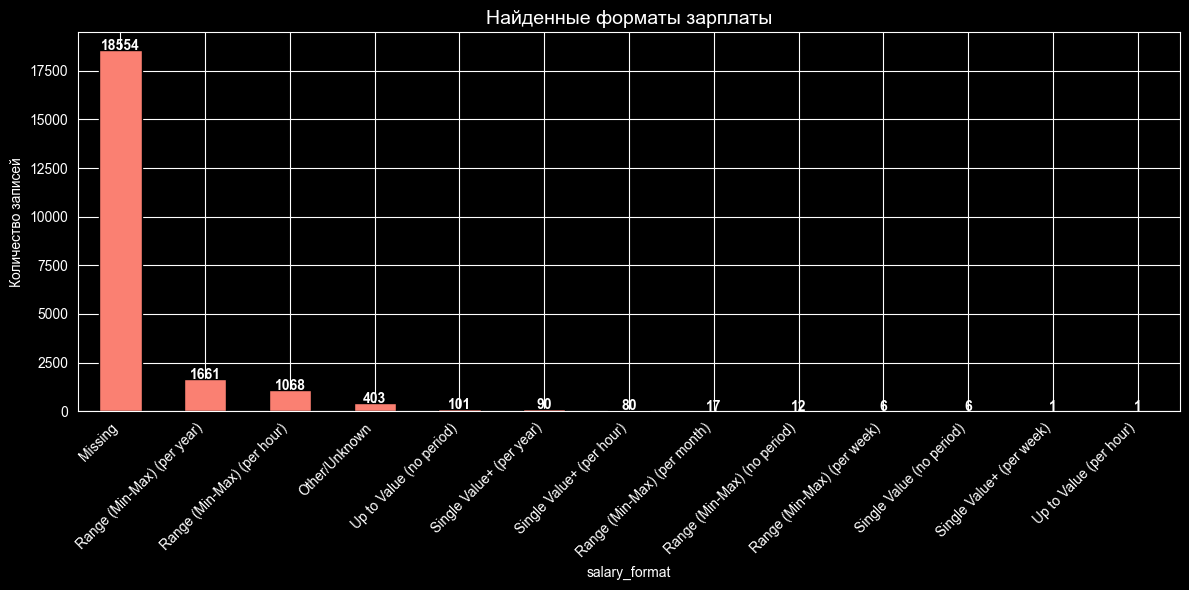

Статистика:
salary_format
Missing                        18554
Range (Min-Max) (per year)      1661
Range (Min-Max) (per hour)      1068
Other/Unknown                    403
Up to Value (no period)          101
Single Value+ (per year)          90
Single Value+ (per hour)          80
Range (Min-Max) (per month)       17
Range (Min-Max) (no period)       12
Range (Min-Max) (per week)         6
Single Value (no period)           6
Single Value+ (per week)           1
Up to Value (per hour)             1
Name: count, dtype: int64


In [10]:
salary_patterns = {
    'Range (Min-Max)': r'.*?\d+.*-.*?\d+.*',
    'Up to Value': r'(?i)up to.*?\d+',
    'Single Value+': r'.*?\d+[\d,.]*\+.*',
    'Single Value': r'^\s*[\$]?\d+[\d,.]*\s*$'
}

def classify_salary_refined(text):
    if pd.isna(text) or str(text).strip() == '':
        return 'Missing'

    text = str(text).strip()

    found_struct = 'Other/Unknown'
    for name, regex in salary_patterns.items():
        if re.search(regex, text):
            found_struct = name
            break

    period = 'no period'
    for p in ['hour', 'year', 'month', 'week']:
        if p in text.lower():
            period = f'per {p}'
            break

    if found_struct == 'Other/Unknown':
        return 'Other/Unknown'

    return f"{found_struct} ({period})"

df['salary_format'] = df['salary'].apply(classify_salary_refined)

format_counts = df['salary_format'].value_counts()

plot_data = format_counts


plt.figure(figsize=(12, 6))
plot_data.plot(kind='bar', color='salmon', edgecolor='black')

plt.title('Найденные форматы зарплаты', fontsize=14)
plt.ylabel('Количество записей')
plt.xticks(rotation=45, ha='right')

for i, v in enumerate(plot_data):
    plt.text(i, v + 5, str(int(v)), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print("Статистика:")
print(format_counts)

#### Задание 2.2

1. Разделите столбец `salary` зарплаты три: `минимальная граница зарплаты`, `максимальная граница зарплаты`, `период`. Если значение суммы указано только одно, считайте, что это минимальная зарплата. Значение суммы в обоих столбцах преобразуйте в формат `float`.
2. Покажите на столбчатой диаграмме с группировкой среднюю и медианную минимальную зарплату в каждом периоде. Сделайте выводы.

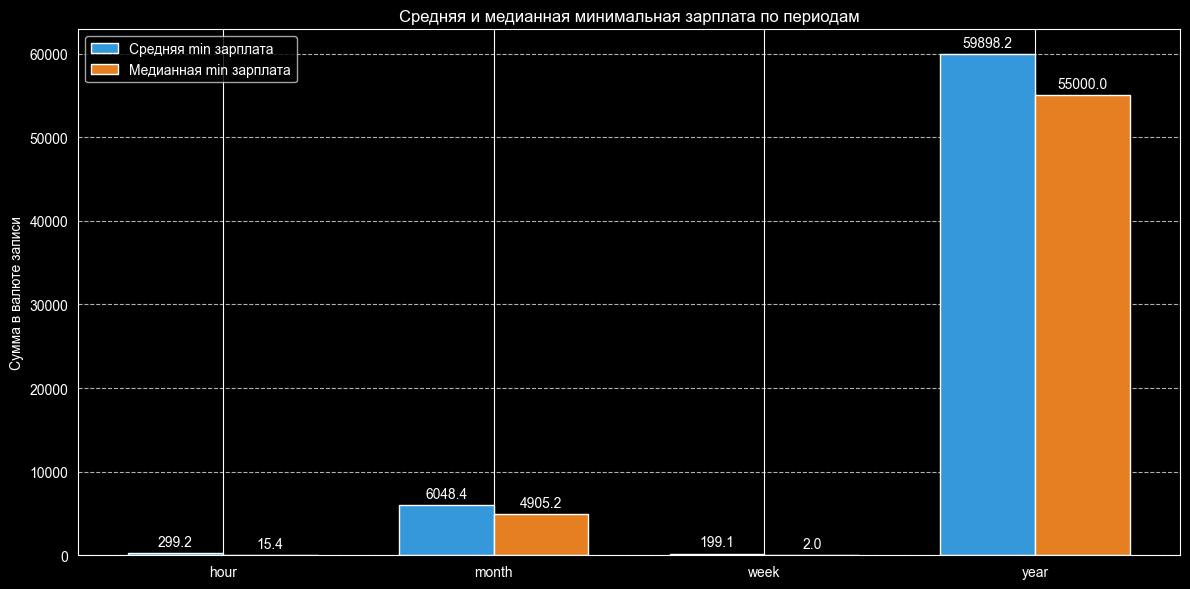

In [11]:
def extract_salary(salary_str):
    if pd.isna(salary_str) or str(salary_str).strip() == '':
        return pd.Series([np.nan, np.nan, None])
    text = str(salary_str).lower().replace(',', '')
    numbers = re.findall(r'\d+\.?\d*', text)
    numbers = [float(n) for n in numbers]

    period = None
    for p in ['hour', 'year', 'month', 'week']:
        if p in text:
            period = p
            break
    min_sal = np.nan
    max_sal = np.nan

    if len(numbers) >= 2:
        min_sal = numbers[0]
        max_sal = numbers[1]
    elif len(numbers) == 1:
        min_sal = numbers[0]
    return pd.Series([min_sal, max_sal, period])

df[['min_salary', 'max_salary', 'period']] = df['salary'].apply(extract_salary)

salary_stats = df.groupby('period')['min_salary'].agg(['mean', 'median']).reset_index()
salary_stats = salary_stats.dropna(subset=['period'])
x = np.arange(len(salary_stats['period']))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, salary_stats['mean'], width, label='Средняя min зарплата', color='#3498db')
rects2 = ax.bar(x + width/2, salary_stats['median'], width, label='Медианная min зарплата', color='#e67e22')

ax.set_ylabel('Сумма в валюте записи')
ax.set_title('Средняя и медианная минимальная зарплата по периодам')
ax.set_xticks(x)
ax.set_xticklabels(salary_stats['period'])
ax.legend()

ax.grid(axis='y', linestyle='--', alpha=0.7)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

#### Задание 2.3

Как было отмечено в задании 2.1, период, за который указывается зарплата, может отсутствовать. Восполните этот пробел в данных следующим образом:

1. Определите диапазон изменения (разброс) значений денежной суммы за каждый из встречающихся в данных периодов. Постройте гистограмму для каждого периода.
2. Определите, к среднему значению за какой период ближе всего сумма, у которой период не указан. Укажите для найденный период. В спорных случаях, где сумма одинаково близка к нескольким диапазонам, не выбирайте ничего.

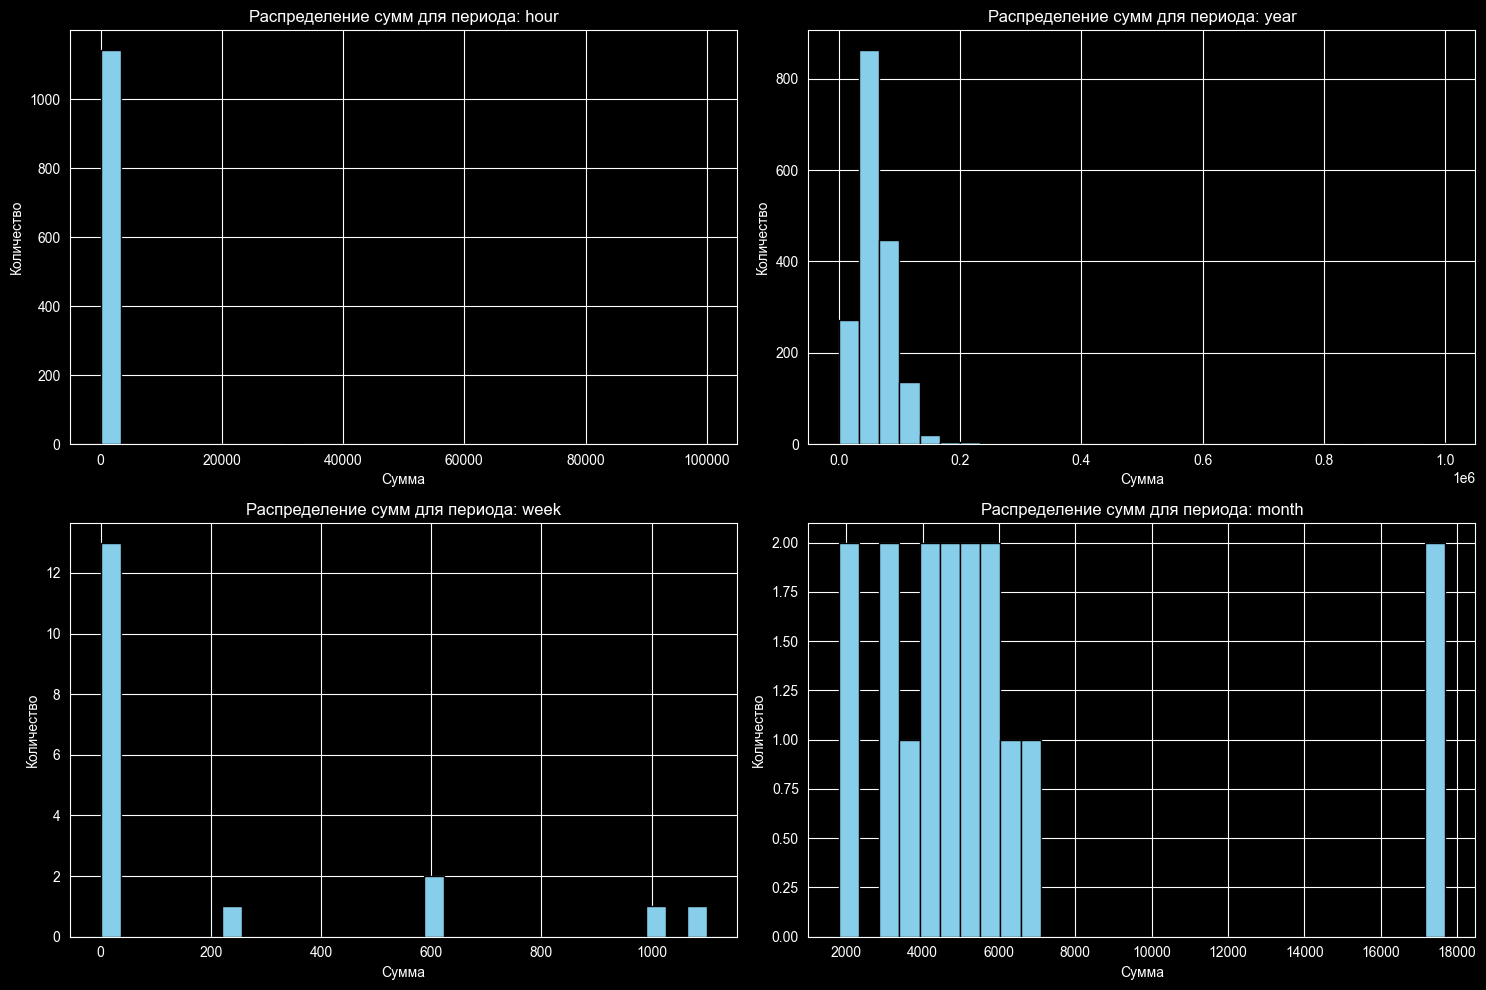

Обновленная статистика по периодам:
period
NaN      18889
year      1798
hour      1191
week        92
month       30
Name: count, dtype: int64


In [12]:
periods_to_check = df['period'].dropna().unique()

plt.figure(figsize=(15, 10))
for i, p in enumerate(periods_to_check, 1):
    plt.subplot(2, 2, i)
    subset = df[df['period'] == p]['min_salary']
    plt.hist(subset, bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Распределение сумм для периода: {p}')
    plt.xlabel('Сумма')
    plt.ylabel('Количество')

plt.tight_layout()
plt.show()

mean_salaries = df.groupby('period')['min_salary'].mean().to_dict()

def impute_period(row, mean_dict):
    if pd.notna(row['period']) or pd.isna(row['min_salary']):
        return row['period']

    val = row['min_salary']
    distances = {p: abs(val - m) for p, m in mean_dict.items()}
    min_dist = min(distances.values())
    best_periods = [p for p, d in distances.items() if d == min_dist]

    if len(best_periods) == 1:
        return best_periods[0]
    return None

df['period'] = df.apply(lambda row: impute_period(row, mean_salaries), axis=1)

print("Обновленная статистика по периодам:")
print(df['period'].value_counts(dropna=False))

### Задание 3

В задании 3 необходимо провести обработку столбца `job_type`. Выясните, какие форматы значений есть в столбце `job_type`. Сделайте выводы. При необходимости – стройте графики.

Исходные значений в job_type:
job_type
Full Time                                        6757
Full Time Employee                               6617
Full Time, Employee                              3360
Full Time Temporary/Contract/Project             1062
Full Time, Temporary/Contract/Project             533
Full Time , Employee                              406
Part Time Employee                                382
Part Time                                         329
Part Time, Employee                               196
Temporary/Contract/Project                        193
Employee                                          147
Full Time / Employee                              121
Full Time , Temporary/Contract/Project             56
Part Time, Temporary/Contract/Project              34
Per Diem, Employee                                 29
Per Diem                                           22
Job Type Full Time Employee                        19
Part Time Seasonal                         

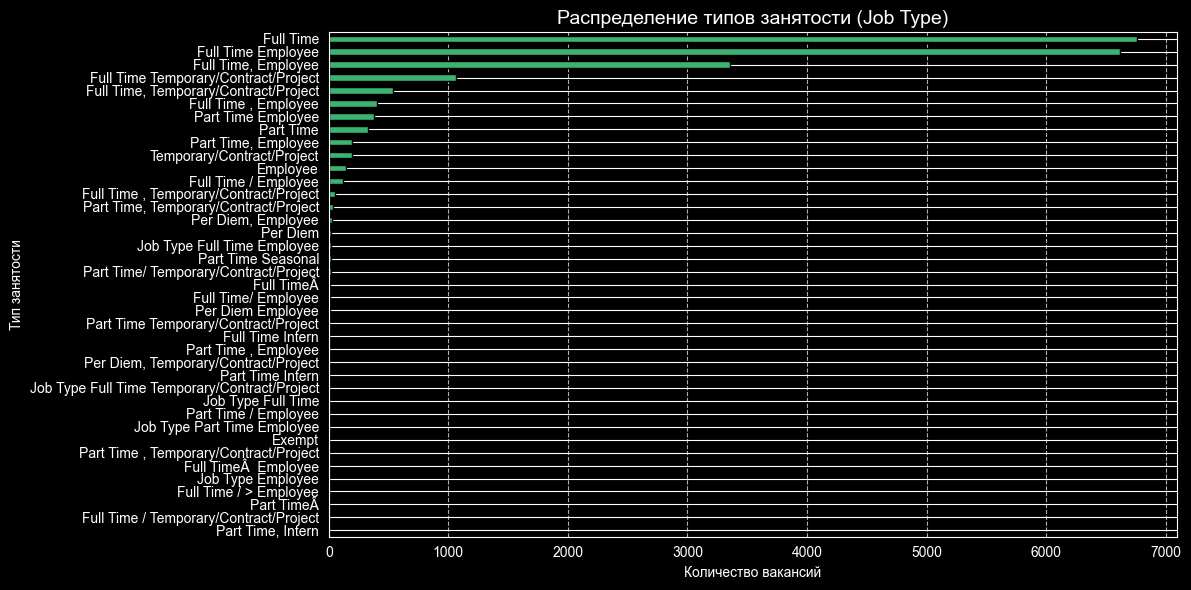


Количество уникальных комбинированных типов: 21


In [13]:
job_type_counts = df['job_type'].str.strip().value_counts()

print("Исходные значений в job_type:")
print(job_type_counts.head(40))

plt.figure(figsize=(12, 6))
job_type_counts.head(40).plot(kind='barh', color='mediumseagreen', edgecolor='black')

plt.title('Распределение типов занятости (Job Type)', fontsize=14)
plt.xlabel('Количество вакансий')
plt.ylabel('Тип занятости')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

multiple_types = df[df['job_type'].str.contains(r'[,/|]', na=False)]['job_type'].unique()
print(f"\nКоличество уникальных комбинированных типов: {len(multiple_types)}")

Вы заметили, что многие значения фактически одинаковые, но немного по-разному отформатированы? Приведем их к единому формату.

Количество уникальных значений ДО: 39
Количество уникальных значений ПОСЛЕ: 5


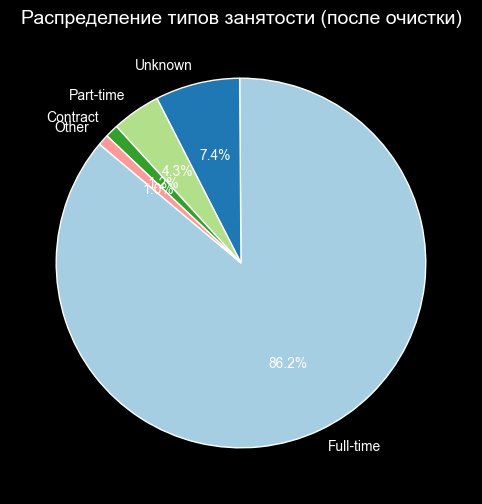


Итоговая статистика по типам занятости:
job_type_clean
Full-time    18970
Unknown       1628
Part-time      936
Contract       254
Other          212
Name: count, dtype: int64


In [14]:
def standardize_job_type(val):
    if pd.isna(val):
        return "Unknown"
    val = str(val).lower().strip()
    if 'full-time' in val or 'full time' in val or 'fulltime' in val:
        return 'Full-time'
    elif 'contract' in val:
        return 'Contract'
    elif 'part-time' in val or 'part time' in val:
        return 'Part-time'
    elif 'intern' in val:
        return 'Internship'
    elif 'temporary' in val or 'temp' in val:
        return 'Temporary'
    else:
        return 'Other'

df['job_type_clean'] = df['job_type'].apply(standardize_job_type)

print("Количество уникальных значений ДО:", df['job_type'].nunique())
print("Количество уникальных значений ПОСЛЕ:", df['job_type_clean'].nunique())

job_type_stats = df['job_type_clean'].value_counts()

plt.figure(figsize=(10, 6))
job_type_stats.plot(kind='pie', autopct='%1.1f%%', colors=plt.cm.Paired.colors, startangle=140)

plt.title('Распределение типов занятости (после очистки)', fontsize=14)
plt.ylabel('')
plt.show()

print("\nИтоговая статистика по типам занятости:")
print(job_type_stats)

Столбец `job_type` состоит из двух частей: "полнота" занятости (`Full Time`, `Part Time`, `Per Diem`) и "тип" занятости (`Employee`, `Intern`). Кроме того, встречаются и неполные записи.

Задание:
1. Написать одно или несколько регулярных выражений для разделения столбца `job_type` на два: `полнота занятости`, `тип занятости`.
2. Если данные о полноте отсутствуют, внесите значение `Full Time`.
Если отсутствуют данные о типе – внесите `Employee`.
3. Постройте столбчатую диаграмму со стековой группировкой для полноты и типа занятости. Сделайте выводы.

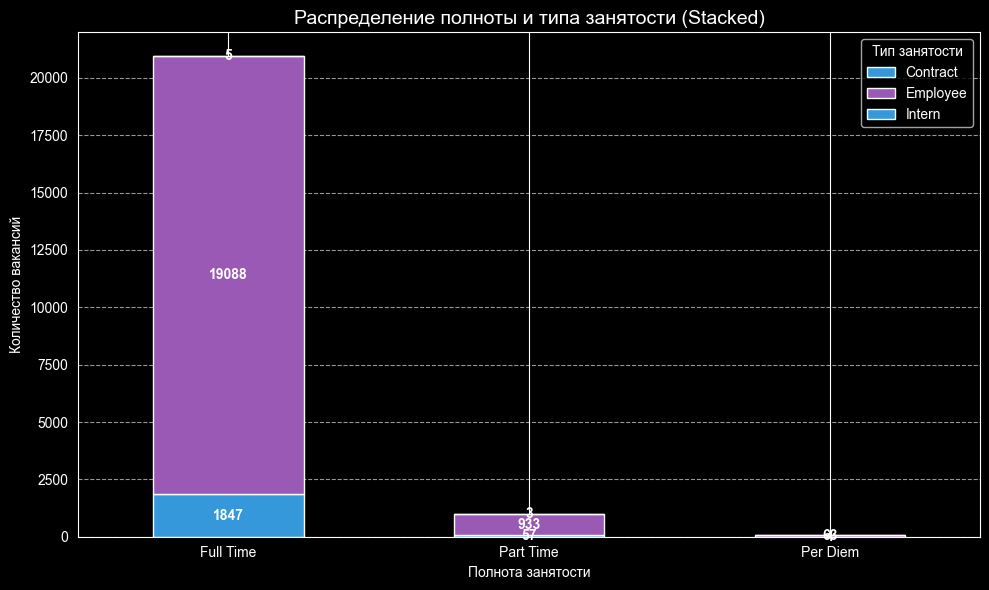

Сводная таблица данных:
job_class     Contract  Employee  Intern
job_fullness                            
Full Time         1847     19088       5
Part Time           57       933       3
Per Diem             4        63       0


In [15]:
def split_job_type(text):
    if pd.isna(text):
        return pd.Series(['Full Time', 'Employee'])

    text = str(text).lower()
    fullness = 'Full Time'
    if re.search(r'part\s*time', text):
        fullness = 'Part Time'
    elif re.search(r'per\s*diem', text):
        fullness = 'Per Diem'

    j_type = 'Employee'
    if re.search(r'intern', text):
        j_type = 'Intern'
    elif re.search(r'contract', text):
        j_type = 'Contract'

    return pd.Series([fullness, j_type])

df[['job_fullness', 'job_class']] = df['job_type'].apply(split_job_type)
stacked_data = pd.crosstab(df['job_fullness'], df['job_class'])

ax = stacked_data.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#3498db', '#9b59b6'])

plt.title('Распределение полноты и типа занятости (Stacked)', fontsize=14)
plt.xlabel('Полнота занятости')
plt.ylabel('Количество вакансий')
plt.xticks(rotation=0)
plt.legend(title='Тип занятости')

plt.grid(axis='y', linestyle='--', alpha=0.6)
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 0:
        x, y = p.get_xy()
        ax.text(x + width/2, y + height/2, f'{int(height)}',
                ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print("Сводная таблица данных:")
print(stacked_data)

# Порядок защиты работы

**Для защиты работы необходимо:**
1. Предоставить результаты выполнения всех заданий в виде ссылки на Google Colab.
2. Выполнить дополнительное задание в процессе сдачи работы. Дополнительное задание представляет собой решение задачи на обработку данных лабораторной работы, меньшее по объему, но сопоставимое по сложности тем заданиям, которые требовалось выполнить в рамках работы.

**Примеры дополнительных заданий:**
1. В столбце `sector` часто представлены данные из столбца `organization` и наоборот. Устраните эту проблему.
2. В столбце `job_title` часто можно частично или полностью встретить указание местоположения организации. Сравните, совпадают ли в таких случаях данные с тем, что указано в столбцах `город`, `код штата`, `почтовый индекс`. Если в этих трех столбцах данные отсутствуют, заполните их данными из столбца `job_title`.
3. Практически во всех столбцах датасета вместо соответствующих названию данных иногда встречается текст из `job_description`. Найдите такие столбцы и записи с описанием вакансии в них. Покажите на столбчатой диаграмме, в каких столбцах и в каком количестве находится информация из столбца `job_description`.

# Дополнительные материалы

1. DAMA-DMBOK: Свод знаний по управлению данными: Второе издание / DAMA International; [пер. с англ.]. – Москва: ООО "Олимп-Бизнес", 2021. – 828 с.
2. Макгрегор, С. Обработка данных на Python: Data Wrangling и Data Quality: [Текст] / С. Макгрегор. – Москва: БХВ, 2024. – 432 с.